In [4]:
import os 
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
folder_path = "../data_raw/tests_matches"

files = os.listdir(folder_path)

print("Total Files: ", len(files))


Total Files:  878


In [4]:
print(files[:5])

['1000851.yaml', '1000853.yaml', '1000855.yaml', '1000881.yaml', '1000883.yaml']


In [ ]:
import os
import yaml 
folder_path = "../data_raw/tests_matches"
files = os.listdir(folder_path)



match_data = []

for file in files:
    file_path = os.path.join(folder_path, file)
    with open(file_path, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)
    info = data['info']

    teams = info['teams']
    outcome = info.get('outcome', {})

    winner = outcome.get('winner')

    win_by_runs = None
    win_by_wickets = None

    if 'by' in outcome:
        win_by_runs = outcome['by'].get('runs')
        win_by_wickets = outcome['by'].get('wickets')

    match_data.append({
        'match_id': file.replace('.yaml', ''),
        'team1': teams[0],
        'team2': teams[1],
        'venue': info.get('venue'),
        'date': info['dates'][0],
        'winner': winner,
        'win_by_runs': win_by_runs,
        'win_by_wickets': win_by_wickets
    })

print("Done:", len(match_data) )

Done: 50


In [12]:
import os
import yaml 

folder_path = "../data_raw/tests_matches"
files = os.listdir(folder_path)

total_files = len(files)
match_data = []

print(f"Total files to process: {total_files}")
print("Starting processing...\n")

for idx, file in enumerate(files, start=1):
    file_path = os.path.join(folder_path, file)
    with open(file_path, 'r', encoding='utf-8') as f:
        data = yaml.safe_load(f)
    info = data['info']

    teams = info['teams']
    outcome = info.get('outcome', {})

    winner = outcome.get('winner')

    win_by_runs = None
    win_by_wickets = None

    if 'by' in outcome:
        win_by_runs = outcome['by'].get('runs')
        win_by_wickets = outcome['by'].get('wickets')

    match_data.append({
        'match_id': file.replace('.yaml', ''),
        'team1': teams[0],
        'team2': teams[1],
        'venue': info.get('venue'),
        'date': info['dates'][0],
        'winner': winner,
        'win_by_runs': win_by_runs,
        'win_by_wickets': win_by_wickets
    })

    # Progress updates every 100 files
    if idx % 100 == 0:
        percentage = (idx / total_files) * 100
        print(f"Loading... {idx} files | Process completed: {percentage:.1f}%")

# Final completion message
percentage = (total_files / total_files) * 100
print(f"\nProcess completed: {percentage:.0f}%")
print(f"Done: {len(match_data)} matches processed")

Total files to process: 878
Starting processing...

Loading... 100 files | Process completed: 11.4%
Loading... 200 files | Process completed: 22.8%
Loading... 300 files | Process completed: 34.2%
Loading... 400 files | Process completed: 45.6%
Loading... 500 files | Process completed: 56.9%
Loading... 600 files | Process completed: 68.3%
Loading... 700 files | Process completed: 79.7%
Loading... 800 files | Process completed: 91.1%


TypeError: string indices must be integers, not 'str'

Starts from here

In [23]:
import os
import yaml 

folder_path = "../data_raw/tests_matches"
files = os.listdir(folder_path)

total_files = len(files)
match_data = []
skipped_files = []

print(f"Total files to process: {total_files}")
print("Starting processing...\n")

for idx, file in enumerate(files, start=1):
    file_path = os.path.join(folder_path, file)
    
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = yaml.safe_load(f)
        
        # Check if data is a dictionary
        if not isinstance(data, dict) or 'info' not in data:
            skipped_files.append((file, "Missing 'info' key or invalid structure"))
            continue
            
        info = data['info']

        teams = info['teams']
        outcome = info.get('outcome', {})

        winner = outcome.get('winner')

        win_by_runs = None
        win_by_wickets = None

        if 'by' in outcome:
            win_by_runs = outcome['by'].get('runs')
            win_by_wickets = outcome['by'].get('wickets')

        match_data.append({
            'match_id': file.replace('.yaml', ''),
            'team1': teams[0],
            'team2': teams[1],
            'venue': info.get('venue'),
            'city': info.get('city'),
            'date': info['dates'][0],
            'winner': winner,
            'win_by_runs': win_by_runs,
            'win_by_wickets': win_by_wickets
        })
    
    except Exception as e:
        skipped_files.append((file, str(e)))
        continue

    # Progress updates every 100 files
    if idx % 100 == 0:
        percentage = (idx / total_files) * 100
        print(f"Loading... {idx} files | Process completed: {percentage:.1f}%")

# Final completion message
percentage = (total_files / total_files) * 100
print(f"\nProcess completed: {percentage:.0f}%")
print(f"Done: {len(match_data)} matches processed")

# Show skipped files if any
if skipped_files:
    print(f"\n⚠️ Skipped {len(skipped_files)} file(s):")
    for file, reason in skipped_files:
        print(f"  - {file}: {reason}")

Total files to process: 878
Starting processing...

Loading... 100 files | Process completed: 11.4%
Loading... 200 files | Process completed: 22.8%
Loading... 300 files | Process completed: 34.2%
Loading... 400 files | Process completed: 45.6%
Loading... 500 files | Process completed: 56.9%
Loading... 600 files | Process completed: 68.3%
Loading... 700 files | Process completed: 79.7%
Loading... 800 files | Process completed: 91.1%

Process completed: 100%
Done: 877 matches processed

⚠️ Skipped 1 file(s):
  - README.txt: Missing 'info' key or invalid structure


In [5]:
#df_match = pd.DataFrame(match_data)

import os 
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df_match = pd.read_csv("../data_processed/match_master.csv")

df_match.head()


df_match

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN
2,1000855,Australia,South Africa,Adelaide Oval,NaN,2016-11-24,Australia,NaN,7.0
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,NaN,2016-12-26,Australia,18.0,NaN
...,...,...,...,...,...,...,...,...,...
872,936149,South Africa,Sri Lanka,Newlands,Cape Town,2017-01-02,South Africa,282.0,NaN
873,936151,South Africa,Sri Lanka,New Wanderers Stadium,Johannesburg,2017-01-12,South Africa,118.0,NaN
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,NaN,2016-07-26,Sri Lanka,106.0,NaN
875,995453,Sri Lanka,Australia,Galle International Stadium,NaN,2016-08-04,Sri Lanka,229.0,NaN


convert the Data Frame to csv

In [ ]:
#df_match.to_csv("../data_processed/match_master.csv", index=False)

df_match.to_csv("../data_processed/master_test_dataset.csv", index=False)

Load the CSV for furthur Data inspection and cleaning


In [1]:
import os 
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("../data_processed/master_test_dataset.csv")

df.columns

Index(['match_id', 'team1', 'team2', 'venue', 'city', 'date', 'winner',
       'win_by_runs', 'win_by_wickets', 'year', 'result_type', 'host_country',
       'home_team', 'away_team'],
      dtype='object')

In [8]:
#df_match = pd.read_csv("../data_processed/match_master.csv")

# Fixing date format

df_match['date'] = pd.to_datetime(df_match['date'])

df_match['year'] = df_match['date'].dt.year

#adding Result type

def get_result(row):
    if pd.notna(row['winner']):
        return 'Win'
    else:
        return 'Draw'

df_match['result_type'] = df_match.apply(get_result, axis=1)

df_match['result_type'].value_counts()

df_match

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win
2,1000855,Australia,South Africa,Adelaide Oval,NaN,2016-11-24,Australia,NaN,7.0,2016,Win
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,NaN,2016-12-26,Australia,18.0,NaN,2016,Win
...,...,...,...,...,...,...,...,...,...,...,...
872,936149,South Africa,Sri Lanka,Newlands,Cape Town,2017-01-02,South Africa,282.0,NaN,2017,Win
873,936151,South Africa,Sri Lanka,New Wanderers Stadium,Johannesburg,2017-01-12,South Africa,118.0,NaN,2017,Win
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,NaN,2016-07-26,Sri Lanka,106.0,NaN,2016,Win
875,995453,Sri Lanka,Australia,Galle International Stadium,NaN,2016-08-04,Sri Lanka,229.0,NaN,2016,Win


In [9]:
df_match.to_csv("../data_processed/match_master.csv", index=False)

df_match = pd.read_csv("../data_processed/match_master.csv")

df_match

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win
2,1000855,Australia,South Africa,Adelaide Oval,NaN,2016-11-24,Australia,NaN,7.0,2016,Win
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,NaN,2016-12-26,Australia,18.0,NaN,2016,Win
...,...,...,...,...,...,...,...,...,...,...,...
872,936149,South Africa,Sri Lanka,Newlands,Cape Town,2017-01-02,South Africa,282.0,NaN,2017,Win
873,936151,South Africa,Sri Lanka,New Wanderers Stadium,Johannesburg,2017-01-12,South Africa,118.0,NaN,2017,Win
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,NaN,2016-07-26,Sri Lanka,106.0,NaN,2016,Win
875,995453,Sri Lanka,Australia,Galle International Stadium,NaN,2016-08-04,Sri Lanka,229.0,NaN,2016,Win


In [10]:
# Timeline investigation

df_match['date'].min()
df_match['date'].max()

#Matches per year

match_per_year = df_match['year'].value_counts().sort_index()

match_per_year

year
2001     1
2002     2
2003    20
2004    17
2005    24
2006    39
2007    30
2008    43
2009    41
2010    43
2011    39
2012    42
2013    44
2014    41
2015    43
2016    47
2017    47
2018    47
2019    36
2020    22
2021    42
2022    43
2023    33
2024    50
2025    40
2026     1
Name: count, dtype: int64

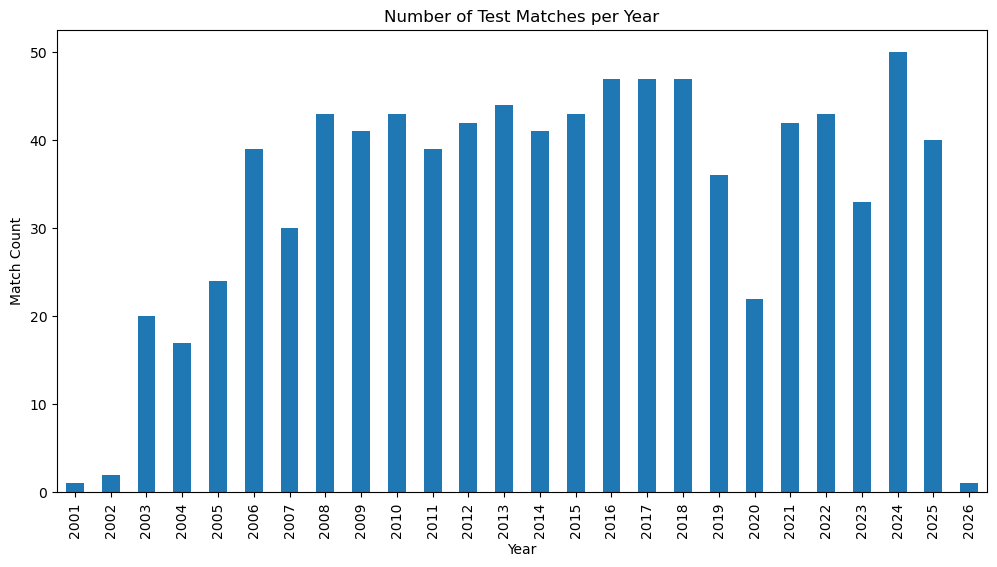

In [11]:
match_per_year.plot(kind='bar', figsize=(12,6))
plt.title('Number of Test Matches per Year')
plt.xlabel('Year')
plt.ylabel('Match Count')
plt.show()

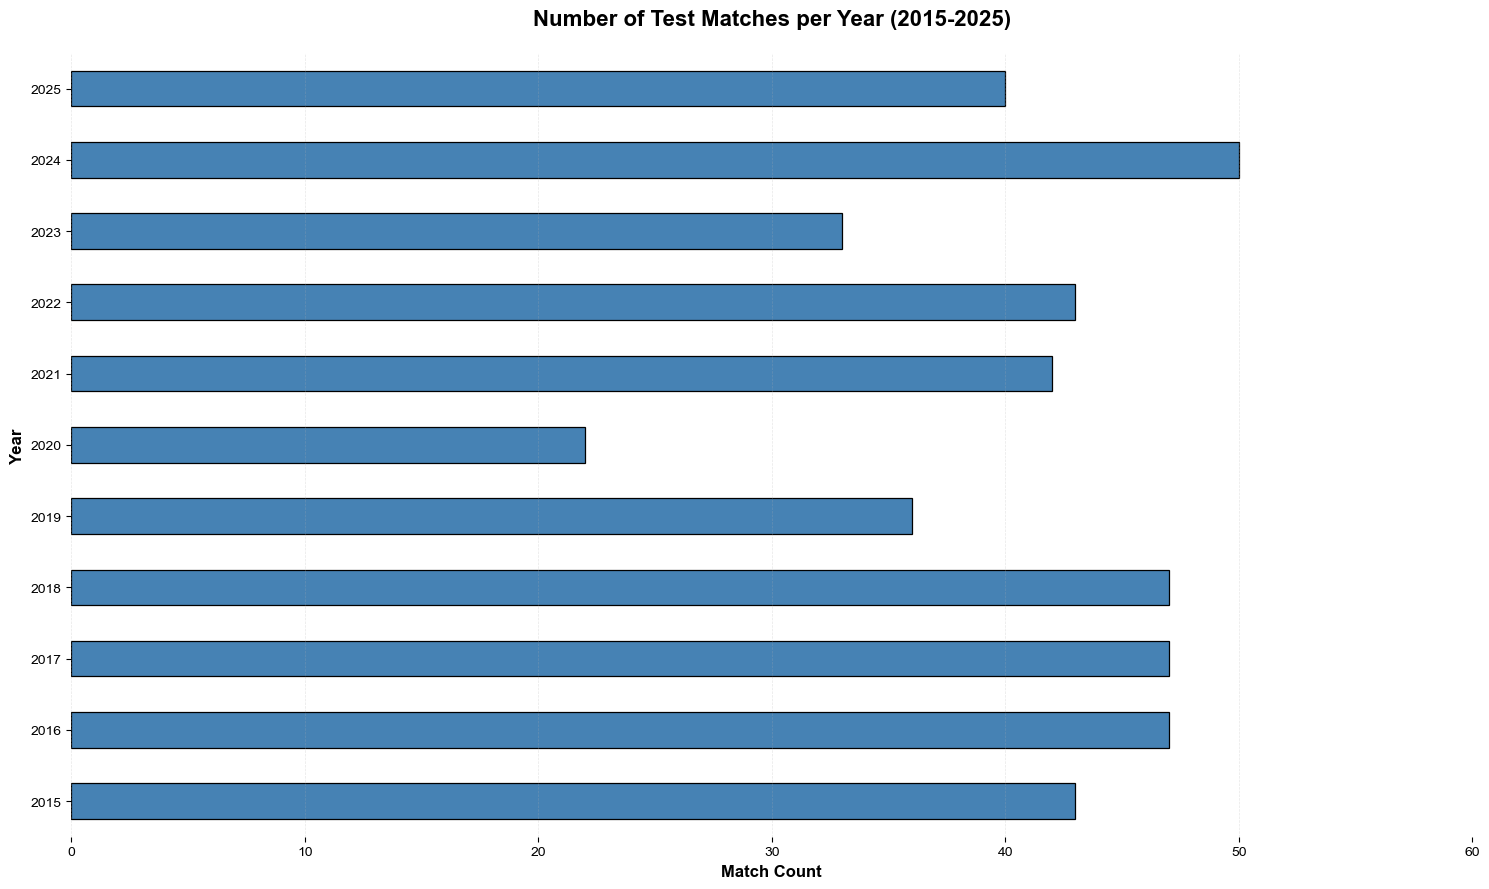

In [12]:
# Year Filtering (2015 -  2025)

df_match_filtered = df_match[(df_match['year'] >= 2015) & (df_match['year'] <= 2025)]

df_match_per_year_filtered = df_match_filtered['year'].value_counts().sort_index()

filter_plot = df_match_per_year_filtered.plot(kind = 'barh', figsize=(15,9), color = 'steelblue', edgecolor='black', linewidth=0.9)
sns.despine(left=True, bottom=True)
sns.set_style('ticks')

plt.title('Number of Test Matches per Year (2015-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Match Count', fontsize=12, fontweight='bold')
plt.ylabel('Year', fontsize=12, fontweight='bold')
plt.xlim(0, df_match_per_year_filtered.max() + 10)

plt.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)


plt.tight_layout()
plt.show()

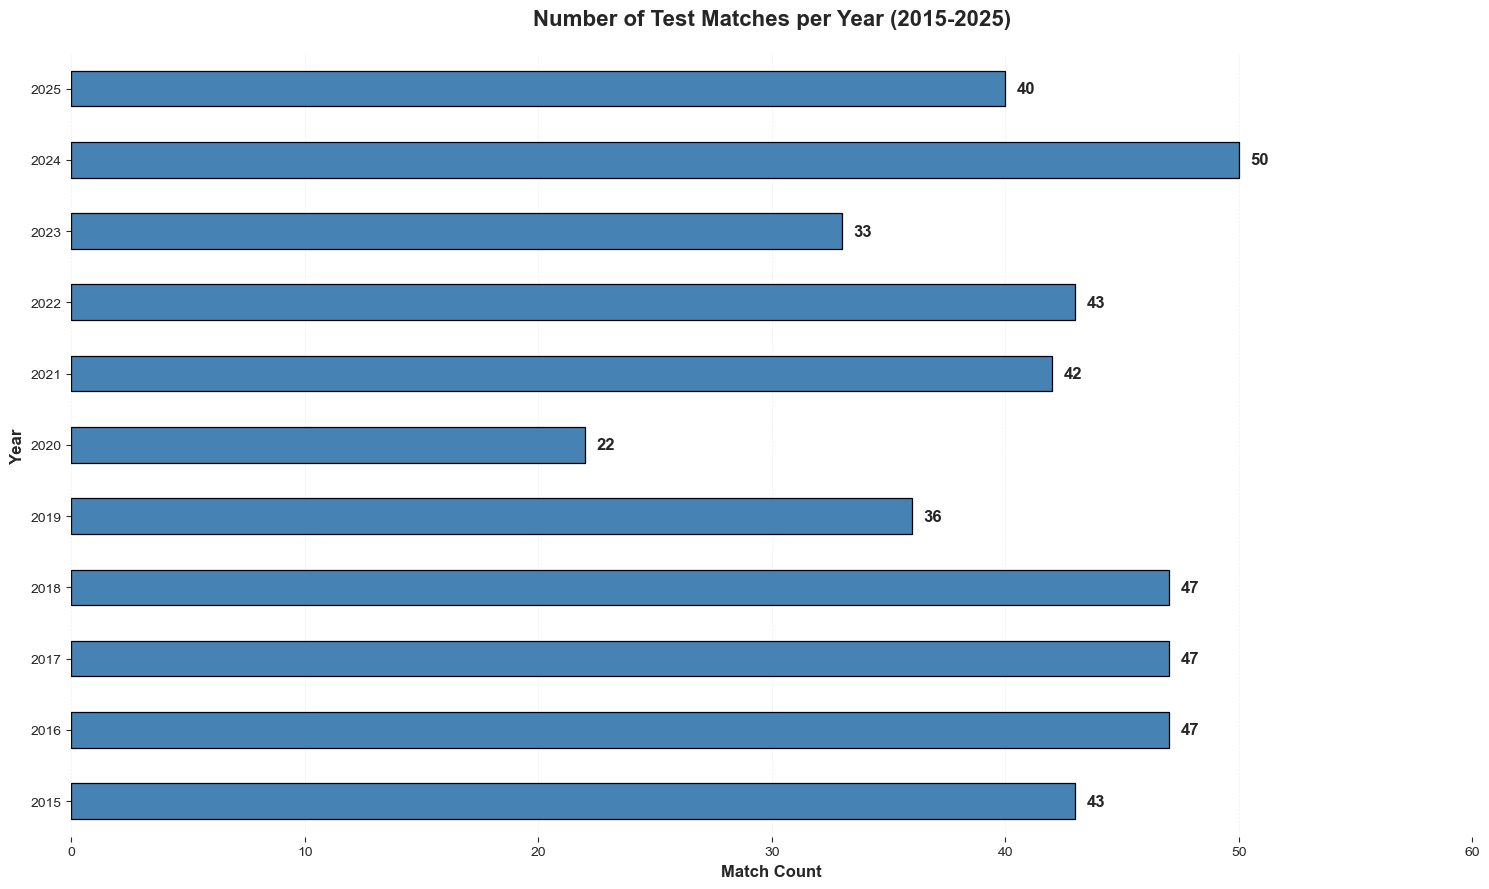

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot
plt.figure(figsize=(15, 9))

ax = df_match_per_year_filtered.plot(
    kind='barh',
    color='steelblue',
    edgecolor='black',
    linewidth=0.9
)

# Styling
sns.despine(left=True, bottom=True)
sns.set_style('ticks')

plt.title('Number of Test Matches per Year (2015-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Match Count', fontsize=12, fontweight='bold')
plt.ylabel('Year', fontsize=12, fontweight='bold')

plt.xlim(0, df_match_per_year_filtered.max() + 10)
plt.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.5)

# 🔥 Add labels
for i, value in enumerate(df_match_per_year_filtered):
    plt.text(
        value + 0.5,   # position (slightly right of bar)
        i,             # y position
        str(value),    # label
        va='center',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

Mapping Venue as either Home or Away


In [14]:
df["city"].nunique()
df["city"].unique()[:20]

array(['Perth', 'Hobart', nan, 'Brisbane', 'Wellington', 'Christchurch',
       'Hamilton', 'Dunedin', 'Antigua', 'Jamaica', 'St Lucia',
       'Trinidad', 'Bulawayo', 'Chittagong', 'Mirpur', 'Kanpur',
       'Kolkata', 'Indore', 'London', 'Nottingham'], dtype=object)

In [15]:
city_country_map = {
    # Australia
    "Perth": "Australia",
    "Hobart": "Australia",
    "Brisbane": "Australia",

    # New Zealand
    "Wellington": "New Zealand",
    "Christchurch": "New Zealand",
    "Hamilton": "New Zealand",
    "Dunedin": "New Zealand",

    # West Indies
    "Antigua": "West Indies",
    "Jamaica": "West Indies",
    "St Lucia": "West Indies",
    "Trinidad": "West Indies",

    # Zimbabwe
    "Bulawayo": "Zimbabwe",

    # Bangladesh
    "Chittagong": "Bangladesh",
    "Mirpur": "Bangladesh",

    # India
    "Kanpur": "India",
    "Kolkata": "India",
    "Indore": "India",

    # England
    "London": "England",
    "Nottingham": "England",
}

In [16]:
df_match_host_country = df_match.copy()

df_match_host_country["host_country"] = df_match_host_country["city"].map(city_country_map)

df_match_host_country["host_country"]

0      Australia
1      Australia
2            NaN
3      Australia
4            NaN
         ...    
872          NaN
873          NaN
874          NaN
875          NaN
876          NaN
Name: host_country, Length: 877, dtype: object

In [17]:
df_match_host_country["host_country"].isna().sum()

df_match_host_country[df_match_host_country["host_country"].isna()]["city"].unique()

array([nan, 'Manchester', 'Birmingham', 'Leeds', 'Rajkot',
       'Visakhapatnam', 'Chandigarh', 'Mumbai', 'Chennai', 'Hyderabad',
       'Abu Dhabi', 'Pune', 'Bengaluru', 'Ranchi', 'Dharamsala',
       'Potchefstroom', 'Bloemfontein', 'Durban', 'Port Elizabeth',
       'Cape Town', 'Johannesburg', 'Barbados', 'Dominica', 'Colombo',
       'Dhaka', 'Chattogram', 'Auckland', 'Southampton', 'Centurion',
       'Nagpur', 'Delhi', 'Dublin', 'Melbourne', 'Sydney', 'Canberra',
       'North Sound', 'Bridgetown', 'Gros Islet', 'Adelaide',
       'Mount Maunganui', 'Kingston', 'Galle', 'Rawalpindi', 'Karachi',
       'Harare', 'Ahmedabad', 'Pallekele', 'Kandy', "St George's",
       'Gqeberha', 'Lahore', 'Multan', 'Roseau', 'Port of Spain',
       'Sylhet', 'Belfast', 'Providence', 'Guwahati', "St John's",
       'Chester-le-Street', 'Faisalabad', 'Bogra', 'Fatullah', 'St Kitts',
       'Napier', 'Guyana', 'Bangalore', 'Cardiff', 'St Vincent',
       'Grenada', 'Khulna', 'Darwin'], dtype=objec

In [18]:
def get_home_team(row):
    if row["team1"] == row["host_country"]:
        return row["team1"]
    elif row["team2"] == row["host_country"]:
        return row["team2"]
    else:
        return "Neutral"

df_match_host_country["home_team"] = df_match_host_country.apply(get_home_team, axis=1)

In [19]:
def get_away_team(row):
    if row["home_team"] == row["team1"]:
        return row["team2"]
    elif row["home_team"] == row["team2"]:
        return row["team1"]
    else:
        return "Neutral"

df_match_host_country["away_team"] = df_match_host_country.apply(get_away_team, axis=1)

In [20]:
df_match_host_country[["team1", "team2", "city", "host_country", "home_team"]].head(10)

,team1,team2,city,host_country,home_team
0,Australia,South Africa,Perth,Australia,Australia
1,Australia,South Africa,Hobart,Australia,Australia
2,Australia,South Africa,NaN,NaN,Neutral
3,Australia,Pakistan,Brisbane,Australia,Australia
4,Australia,Pakistan,NaN,NaN,Neutral
5,Australia,Pakistan,NaN,NaN,Neutral
6,New Zealand,Bangladesh,Wellington,New Zealand,New Zealand
7,New Zealand,Bangladesh,Christchurch,New Zealand,New Zealand
8,New Zealand,Pakistan,Christchurch,New Zealand,New Zealand
9,New Zealand,Pakistan,Hamilton,New Zealand,New Zealand


Fixing unmapped cities 


In [21]:
df_match_host_country[df_match_host_country["host_country"].isna()]["city"].unique()

array([nan, 'Manchester', 'Birmingham', 'Leeds', 'Rajkot',
       'Visakhapatnam', 'Chandigarh', 'Mumbai', 'Chennai', 'Hyderabad',
       'Abu Dhabi', 'Pune', 'Bengaluru', 'Ranchi', 'Dharamsala',
       'Potchefstroom', 'Bloemfontein', 'Durban', 'Port Elizabeth',
       'Cape Town', 'Johannesburg', 'Barbados', 'Dominica', 'Colombo',
       'Dhaka', 'Chattogram', 'Auckland', 'Southampton', 'Centurion',
       'Nagpur', 'Delhi', 'Dublin', 'Melbourne', 'Sydney', 'Canberra',
       'North Sound', 'Bridgetown', 'Gros Islet', 'Adelaide',
       'Mount Maunganui', 'Kingston', 'Galle', 'Rawalpindi', 'Karachi',
       'Harare', 'Ahmedabad', 'Pallekele', 'Kandy', "St George's",
       'Gqeberha', 'Lahore', 'Multan', 'Roseau', 'Port of Spain',
       'Sylhet', 'Belfast', 'Providence', 'Guwahati', "St John's",
       'Chester-le-Street', 'Faisalabad', 'Bogra', 'Fatullah', 'St Kitts',
       'Napier', 'Guyana', 'Bangalore', 'Cardiff', 'St Vincent',
       'Grenada', 'Khulna', 'Darwin'], dtype=objec

In [22]:
city_country_map.update({

    # England
    "Manchester": "England",
    "Birmingham": "England",
    "Leeds": "England",
    "Southampton": "England",
    "Chester-le-Street": "England",
    "Cardiff": "England",

    # India
    "Rajkot": "India",
    "Visakhapatnam": "India",
    "Chandigarh": "India",
    "Mumbai": "India",
    "Chennai": "India",
    "Hyderabad": "India",
    "Pune": "India",
    "Bengaluru": "India",
    "Bangalore": "India",
    "Ranchi": "India",
    "Dharamsala": "India",
    "Nagpur": "India",
    "Delhi": "India",
    "Ahmedabad": "India",
    "Guwahati": "India",

    # UAE (Neutral venues)
    "Abu Dhabi": "Neutral",
    "Dubai": "Neutral",
    "Sharjah": "Neutral",

    # South Africa
    "Potchefstroom": "South Africa",
    "Bloemfontein": "South Africa",
    "Durban": "South Africa",
    "Port Elizabeth": "South Africa",
    "Cape Town": "South Africa",
    "Johannesburg": "South Africa",
    "Centurion": "South Africa",
    "Gqeberha": "South Africa",

    # West Indies
    "Barbados": "West Indies",
    "Dominica": "West Indies",
    "North Sound": "West Indies",
    "Bridgetown": "West Indies",
    "Gros Islet": "West Indies",
    "Kingston": "West Indies",
    "Roseau": "West Indies",
    "Port of Spain": "West Indies",
    "Providence": "West Indies",
    "St George's": "West Indies",
    "St John's": "West Indies",
    "St Kitts": "West Indies",
    "St Vincent": "West Indies",
    "Grenada": "West Indies",
    "Guyana": "West Indies",

    # Sri Lanka
    "Colombo": "Sri Lanka",
    "Galle": "Sri Lanka",
    "Pallekele": "Sri Lanka",
    "Kandy": "Sri Lanka",

    # Bangladesh
    "Dhaka": "Bangladesh",
    "Chattogram": "Bangladesh",
    "Sylhet": "Bangladesh",
    "Khulna": "Bangladesh",
    "Bogra": "Bangladesh",
    "Fatullah": "Bangladesh",

    # New Zealand
    "Auckland": "New Zealand",
    "Mount Maunganui": "New Zealand",
    "Napier": "New Zealand",

    # Australia
    "Melbourne": "Australia",
    "Sydney": "Australia",
    "Canberra": "Australia",
    "Adelaide": "Australia",
    "Darwin": "Australia",

    # Ireland
    "Dublin": "Ireland",
    "Belfast": "Ireland",

    # Pakistan
    "Rawalpindi": "Pakistan",
    "Karachi": "Pakistan",
    "Lahore": "Pakistan",
    "Multan": "Pakistan",
    "Faisalabad": "Pakistan",

    # Zimbabwe
    "Harare": "Zimbabwe",

    "Galle International Stadium": "Galle",
    "Adelaide Oval": "Adelaide",
    "Sydney Cricket Ground": "Sydney",
    "Melbourne Cricket Ground": "Melbourne",
    "Dubai International Cricket Stadium": "Dubai",
    "Harare Sports Club": "Harare",
    "Pallekele International Cricket Stadium": "Pallekele",
    "Sharjah Cricket Stadium": "Sharjah",
    "Chittagong Divisional Stadium": "Chittagong",
    "Perth Stadium": "Perth",
    "Sylhet International Cricket Stadium": "Sylhet",
    "Multan Cricket Stadium": "Multan",
})

In [23]:
df_match_host_country["host_country"] = df_match_host_country["city"].map(city_country_map)

df_match_host_country["host_country"].isna().sum()

df_match_host_country["host_country"].fillna("Neutral", inplace=True)

df_match_host_country[["team1", "team2", "city", "host_country"]].sample(10)

C:\Users\sujay\AppData\Local\Temp\ipykernel_17516\2196362595.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_match_host_country["host_country"].fillna("Neutral", inplace=True)


,team1,team2,city,host_country
220,New Zealand,England,Leeds,England
685,New Zealand,England,Dunedin,New Zealand
617,South Africa,Australia,Cape Town,South Africa
24,England,South Africa,London,England
13,West Indies,India,Antigua,West Indies
589,Sri Lanka,India,Colombo,Sri Lanka
592,South Africa,India,Centurion,South Africa
728,South Africa,Pakistan,Lahore,Pakistan
164,Pakistan,Sri Lanka,Karachi,Pakistan
394,England,Australia,Nottingham,England


In [24]:
def get_host_country(row):
    city = row["city"]
    venue = row["venue"]

    # First try city
    if pd.notna(city) and city in city_country_map:
        return city_country_map[city]

    # Fallback: check venue string
    for country in city_country_map.values():
        if country in str(venue):
            return country

    return "Neutral"

In [25]:
def get_away_team(row):
    if row["home_team"] == row["team1"]:
        return row["team2"]
    elif row["home_team"] == row["team2"]:
        return row["team1"]
    else:
        return "Neutral"

df_match_host_country["away_team"] = df_match_host_country.apply(get_away_team, axis=1)

In [26]:
df_India_Match["host_country"] = df_India_Match.apply(get_host_country, axis=1)

df_India_Match["host_country"].value_counts()

df_India_Match["host_country"].isna().sum()

NameError: name 'df_India_Match' is not defined

In [27]:
df_match_host_country["india_home"] = (df_match_host_country["home_team"] == "India")
df_match_host_country["india_away"] = (df_match_host_country["away_team"] == "India")

df_match_host_country["india_home"].value_counts()

df_match_host_country["india_away"].value_counts()

india_away
False    837
True      40
Name: count, dtype: int64

In [28]:
df_match_host_country[["team1", "team2", "city", "host_country", "home_team", "away_team"]].head(10)

,team1,team2,city,host_country,home_team,away_team
0,Australia,South Africa,Perth,Australia,Australia,South Africa
1,Australia,South Africa,Hobart,Australia,Australia,South Africa
2,Australia,South Africa,NaN,Neutral,Neutral,Neutral
3,Australia,Pakistan,Brisbane,Australia,Australia,Pakistan
4,Australia,Pakistan,NaN,Neutral,Neutral,Neutral
5,Australia,Pakistan,NaN,Neutral,Neutral,Neutral
6,New Zealand,Bangladesh,Wellington,New Zealand,New Zealand,Bangladesh
7,New Zealand,Bangladesh,Christchurch,New Zealand,New Zealand,Bangladesh
8,New Zealand,Pakistan,Christchurch,New Zealand,New Zealand,Pakistan
9,New Zealand,Pakistan,Hamilton,New Zealand,New Zealand,Pakistan


In [29]:
df_match_host_country.to_csv("../data_processed/match_master_final.csv", index=False)

Investigation of Indian Team performance in Home and Away since 2015

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_Match = pd.read_csv("../data_processed/match_master_final.csv")
df_Match['date'] = pd.to_datetime(df_Match['date'])
df_Match['year'] = df_Match['date'].dt.year

df_Match['city'].isna().sum()
df_Match[df_Match['city'].isna()][['team1', 'team2', 'venue','city', 'host_country']]
df_India_Match = df_Match[(df_Match['year'] >= 2015) & (df_Match['year'] <= 2025)]

df_India_Match = df_Match[(df_Match['team1'] == 'India') | (df_Match['team2'] == 'India')]

df_India_Match_neutral = df_India_Match[df_India_Match['host_country'] == 'Neutral']

df_India_Match_neutral

df_India_Match_neutral.count()

#Timeline Filtering
start_year = 2015
end_year = 2025

#Country Filtering
country = 'India'

df_India_Match['host_country'] = df_India_Match.apply(get_host_country, axis=1)

df_India_Match['host_country'].value_counts()

df_India_Match['host_country'].isna().sum()


#df_India_Match = df_Match[(df_Match['year'] >= 2015) & (df_Match['year'] <= 2025)]

#df_India_Match = df_Match[(df_Match['team1'] == 'India') | (df_Match['team2'] == 'India')]

#df_India_Match_neutral = df_India_Match[df_India_Match['host_country'] == 'Neutral']

#df_India_Match_neutral

#df_India_Match_neutral.count()

#df_Match['city'].isna().sum()

df_India_Match['host_country'] = df_India_Match.apply(get_host_country, axis=1)

df_India_Match['host_country'].value_counts()

df_India_Match['host_country'].isna().sum()

df_India_Match['city'].isna().sum()




C:\Users\sujay\AppData\Local\Temp\ipykernel_17516\4106209585.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_India_Match['host_country'] = df_India_Match.apply(get_host_country, axis=1)
C:\Users\sujay\AppData\Local\Temp\ipykernel_17516\4106209585.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_India_Match['host_country'] = df_India_Match.apply(get_host_country, axis=1)


np.int64(16)

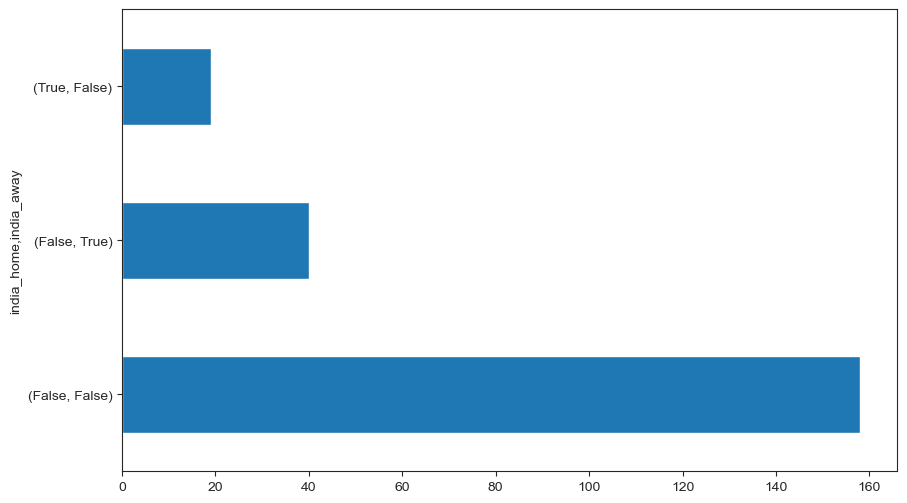

In [32]:
df_Match_filtered = df_Match[(df_Match['year'] >= 2015) & (df_Match['year'] <= 2025)]

df_Match_filtered = df_India_Match.groupby(['india_home', 'india_away'])['year'].size().plot(kind='barh', figsize=(10,6))

#df_Match_filtered

In [33]:
df_neutral = df_Match[
    (df_Match['host_country'] == 'Neutral') & 
    (df_Match['year'] >= 2015) & (df_Match['year'] <= 2025) & 
    ((df_Match['team1'] == 'India') | (df_Match['team2'] == 'India'))
]
df_neutral

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,india_home,india_away


In [34]:
df_match

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win
2,1000855,Australia,South Africa,Adelaide Oval,NaN,2016-11-24,Australia,NaN,7.0,2016,Win
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,NaN,2016-12-26,Australia,18.0,NaN,2016,Win
...,...,...,...,...,...,...,...,...,...,...,...
872,936149,South Africa,Sri Lanka,Newlands,Cape Town,2017-01-02,South Africa,282.0,NaN,2017,Win
873,936151,South Africa,Sri Lanka,New Wanderers Stadium,Johannesburg,2017-01-12,South Africa,118.0,NaN,2017,Win
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,NaN,2016-07-26,Sri Lanka,106.0,NaN,2016,Win
875,995453,Sri Lanka,Australia,Galle International Stadium,NaN,2016-08-04,Sri Lanka,229.0,NaN,2016,Win


In [35]:
df_Match

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,india_home,india_away


In [36]:
df_Match_filtered = df_Match.groupby(['india_home', 'india_away'])['year'].size()

df_Match_filtered

india_home  india_away
False       False         98
Name: year, dtype: int64

In [37]:
df_Match = df_Match[df_Match['city'].isna()]
df_Match

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,india_home,india_away


In [38]:
venue_city_map = {
    "Galle International Stadium": "Galle",
    "Adelaide Oval": "Adelaide",
    "Sydney Cricket Ground": "Sydney",
    "Melbourne Cricket Ground": "Melbourne",
    "Dubai International Cricket Stadium": "Dubai",
    "Harare Sports Club": "Harare",
    "Pallekele International Cricket Stadium": "Pallekele",
    "Sharjah Cricket Stadium": "Sharjah",
    "Chittagong Divisional Stadium": "Chittagong",
    "Perth Stadium": "Perth",
    "Sylhet International Cricket Stadium": "Sylhet",
    "Multan Cricket Stadium": "Multan",
}

In [39]:
df_Match["city"] = df_Match.apply(
    lambda row: venue_city_map.get(row["venue"], row["city"])
    if pd.isna(row["city"])
    else row["city"],
    axis=1
)

C:\Users\sujay\AppData\Local\Temp\ipykernel_17516\633526114.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Match["city"] = df_Match.apply(


In [40]:
df_Match["host_country"] = df_Match["city"].map(city_country_map)

df_Match["home_team"] = df_Match.apply(get_home_team, axis=1)
df_Match["away_team"] = df_Match.apply(get_away_team, axis=1)

df_Match["city"].isna().sum()

C:\Users\sujay\AppData\Local\Temp\ipykernel_17516\1786227893.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Match["host_country"] = df_Match["city"].map(city_country_map)
C:\Users\sujay\AppData\Local\Temp\ipykernel_17516\1786227893.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_Match["home_team"] = df_Match.apply(get_home_team, axis=1)
C:\Users\sujay\AppData\Local\Temp\ipykernel_17516\1786227893.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.

np.int64(0)

In [41]:
df_Match

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,india_home,india_away
2,1000855,Australia,South Africa,Adelaide Oval,Adelaide,2016-11-24,Australia,NaN,7.0,2016,Win,Australia,Australia,South Africa,False,False
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,Melbourne,2016-12-26,Australia,18.0,NaN,2016,Win,Australia,Australia,Pakistan,False,False
5,1000885,Australia,Pakistan,Sydney Cricket Ground,Sydney,2017-01-03,Australia,220.0,NaN,2017,Win,Australia,Australia,Pakistan,False,False
37,1050229,Pakistan,West Indies,Dubai International Cricket Stadium,Dubai,2016-10-13,Pakistan,56.0,NaN,2016,Win,Neutral,Neutral,Neutral,False,False
39,1050233,Pakistan,West Indies,Sharjah Cricket Stadium,Sharjah,2016-10-30,West Indies,NaN,5.0,2016,Win,Neutral,Neutral,Neutral,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
850,902637,England,Pakistan,Dubai International Cricket Stadium,Dubai,2015-10-22,Pakistan,178.0,NaN,2015,Win,Neutral,Neutral,Neutral,False,False
851,902639,England,Pakistan,Sharjah Cricket Stadium,Sharjah,2015-11-01,Pakistan,127.0,NaN,2015,Win,Neutral,Neutral,Neutral,False,False
867,915773,Sri Lanka,West Indies,Galle International Stadium,Galle,2015-10-14,Sri Lanka,6.0,NaN,2015,Win,Sri Lanka,Sri Lanka,West Indies,False,False
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,Pallekele,2016-07-26,Sri Lanka,106.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,False,False


Started from hereeeee

In [29]:
import pandas as pd

df_full = pd.read_csv("../data_processed/master_test_dataset_1.csv")

df_full['date'] = pd.to_datetime(df_full['date'])
df_full['year'] = df_full['date'].dt.year

df_full

#df_full

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,opponent,location,result
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
2,1000855,Australia,South Africa,Adelaide Oval,Adelaide,2016-11-24,Australia,NaN,7.0,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win,Australia,Australia,Pakistan,Australia,Neutral,Loss
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,Melbourne,2016-12-26,Australia,18.0,NaN,2016,Win,Australia,Australia,Pakistan,Australia,Neutral,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,936149,South Africa,Sri Lanka,Newlands,Cape Town,2017-01-02,South Africa,282.0,NaN,2017,Win,South Africa,South Africa,Sri Lanka,South Africa,Neutral,Loss
873,936151,South Africa,Sri Lanka,New Wanderers Stadium,Johannesburg,2017-01-12,South Africa,118.0,NaN,2017,Win,South Africa,South Africa,Sri Lanka,South Africa,Neutral,Loss
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,Pallekele,2016-07-26,Sri Lanka,106.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss
875,995453,Sri Lanka,Australia,Galle International Stadium,Galle,2016-08-04,Sri Lanka,229.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss


In [30]:
df = df_full[(df_full["year"] >= 2015) & (df_full["year"] <= 2025)].copy()

df

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,opponent,location,result
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
2,1000855,Australia,South Africa,Adelaide Oval,Adelaide,2016-11-24,Australia,NaN,7.0,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win,Australia,Australia,Pakistan,Australia,Neutral,Loss
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,Melbourne,2016-12-26,Australia,18.0,NaN,2016,Win,Australia,Australia,Pakistan,Australia,Neutral,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,936149,South Africa,Sri Lanka,Newlands,Cape Town,2017-01-02,South Africa,282.0,NaN,2017,Win,South Africa,South Africa,Sri Lanka,South Africa,Neutral,Loss
873,936151,South Africa,Sri Lanka,New Wanderers Stadium,Johannesburg,2017-01-12,South Africa,118.0,NaN,2017,Win,South Africa,South Africa,Sri Lanka,South Africa,Neutral,Loss
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,Pallekele,2016-07-26,Sri Lanka,106.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss
875,995453,Sri Lanka,Australia,Galle International Stadium,Galle,2016-08-04,Sri Lanka,229.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss


Venue, City, Country mapping

In [31]:
venue_city_map = {
    "Galle International Stadium": "Galle",
    "Adelaide Oval": "Adelaide",
    "Sydney Cricket Ground": "Sydney",
    "Melbourne Cricket Ground": "Melbourne",
    "Dubai International Cricket Stadium": "Dubai",
    "Harare Sports Club": "Harare",
    "Pallekele International Cricket Stadium": "Pallekele",
    "Sharjah Cricket Stadium": "Sharjah",
    "Chittagong Divisional Stadium": "Chittagong",
    "Perth Stadium": "Perth",
    "Sylhet International Cricket Stadium": "Sylhet",
    "Multan Cricket Stadium": "Multan",
}

df["city"] = df.apply(
    lambda row: venue_city_map.get(row["venue"], row["city"])
    if pd.isna(row["city"])
    else row["city"],
    axis=1
)



In [32]:
import pandas as pd

# Define the city-to-country mapping
city_country_map = {
    # England
    "Manchester": "England",
    "Birmingham": "England",
    "Leeds": "England",
    "Southampton": "England",
    "Chester-le-Street": "England",
    "Cardiff": "England",

    # India
    "Rajkot": "India",
    "Visakhapatnam": "India",
    "Chandigarh": "India",
    "Mumbai": "India",
    "Chennai": "India",
    "Hyderabad": "India",
    "Pune": "India",
    "Bengaluru": "India",
    "Bangalore": "India",
    "Ranchi": "India",
    "Dharamsala": "India",
    "Nagpur": "India",
    "Delhi": "India",
    "Ahmedabad": "India",
    "Guwahati": "India",

    # UAE (Neutral venues)
    "Abu Dhabi": "Neutral",
    "Dubai": "Neutral",
    "Sharjah": "Neutral",

    # South Africa
    "Potchefstroom": "South Africa",
    "Bloemfontein": "South Africa",
    "Durban": "South Africa",
    "Port Elizabeth": "South Africa",
    "Cape Town": "South Africa",
    "Johannesburg": "South Africa",
    "Centurion": "South Africa",
    "Gqeberha": "South Africa",

    # West Indies
    "Barbados": "West Indies",
    "Dominica": "West Indies",
    "North Sound": "West Indies",
    "Bridgetown": "West Indies",
    "Gros Islet": "West Indies",
    "Kingston": "West Indies",
    "Roseau": "West Indies",
    "Port of Spain": "West Indies",
    "Providence": "West Indies",
    "St George's": "West Indies",
    "St John's": "West Indies",
    "St Kitts": "West Indies",
    "St Vincent": "West Indies",
    "Grenada": "West Indies",
    "Guyana": "West Indies",

    # Sri Lanka
    "Colombo": "Sri Lanka",
    "Galle": "Sri Lanka",
    "Pallekele": "Sri Lanka",
    "Kandy": "Sri Lanka",

    # Bangladesh
    "Dhaka": "Bangladesh",
    "Chattogram": "Bangladesh",
    "Sylhet": "Bangladesh",
    "Khulna": "Bangladesh",
    "Bogra": "Bangladesh",
    "Fatullah": "Bangladesh",

    # New Zealand
    "Auckland": "New Zealand",
    "Mount Maunganui": "New Zealand",
    "Napier": "New Zealand",

    # Australia
    "Melbourne": "Australia",
    "Sydney": "Australia",
    "Canberra": "Australia",
    "Adelaide": "Australia",
    "Darwin": "Australia",

    # Ireland
    "Dublin": "Ireland",
    "Belfast": "Ireland",

    # Pakistan
    "Rawalpindi": "Pakistan",
    "Karachi": "Pakistan",
    "Lahore": "Pakistan",
    "Multan": "Pakistan",
    "Faisalabad": "Pakistan",

    # Zimbabwe
    "Harare": "Zimbabwe",
}


df["host_country"] = df["city"].map(city_country_map)

def get_home_team(row):
    if row['host_country'] == row['team1']:
        return row['team1']
    elif row['host_country'] == row['team2']:
        return row['team2']
    else:
        return row['team1']

df["home_team"] = df.apply(get_home_team, axis=1)

def get_away_team(row):
    if row['home_team'] == row['team1']:
        return row['team2']
    elif row['home_team'] == row['team2']:
        return row['team1']
    else:
        return row['team2']
df["away_team"] = df.apply(get_away_team, axis=1)

In [33]:
df

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,opponent,location,result
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win,NaN,Australia,South Africa,Australia,Neutral,Loss
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win,NaN,Australia,South Africa,Australia,Neutral,Loss
2,1000855,Australia,South Africa,Adelaide Oval,Adelaide,2016-11-24,Australia,NaN,7.0,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win,NaN,Australia,Pakistan,Australia,Neutral,Loss
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,Melbourne,2016-12-26,Australia,18.0,NaN,2016,Win,Australia,Australia,Pakistan,Australia,Neutral,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,936149,South Africa,Sri Lanka,Newlands,Cape Town,2017-01-02,South Africa,282.0,NaN,2017,Win,South Africa,South Africa,Sri Lanka,South Africa,Neutral,Loss
873,936151,South Africa,Sri Lanka,New Wanderers Stadium,Johannesburg,2017-01-12,South Africa,118.0,NaN,2017,Win,South Africa,South Africa,Sri Lanka,South Africa,Neutral,Loss
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,Pallekele,2016-07-26,Sri Lanka,106.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss
875,995453,Sri Lanka,Australia,Galle International Stadium,Galle,2016-08-04,Sri Lanka,229.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss


In [51]:
# Country filtering
country = 'Australia'

#Timeline Filtering
start_year = 2012
end_year = 2026

#Filtering

df_country = df[(df['team1'] == country) | (df['team2'] == country)]
df_country = df_country[(df_country['year'] >= start_year) & (df_country['year'] <= end_year)]

df_country

,match_id,team1,team2,venue,city,date,winner,win_by_runs,win_by_wickets,year,result_type,host_country,home_team,away_team,opponent,location,result
0,1000851,Australia,South Africa,Western Australia Cricket Association Ground,Perth,2016-11-03,South Africa,177.0,NaN,2016,Win,NaN,Australia,South Africa,Australia,Neutral,Loss
1,1000853,Australia,South Africa,Bellerive Oval,Hobart,2016-11-12,South Africa,80.0,NaN,2016,Win,NaN,Australia,South Africa,Australia,Neutral,Loss
2,1000855,Australia,South Africa,Adelaide Oval,Adelaide,2016-11-24,Australia,NaN,7.0,2016,Win,Australia,Australia,South Africa,Australia,Neutral,Loss
3,1000881,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Brisbane,2016-12-15,Australia,39.0,NaN,2016,Win,NaN,Australia,Pakistan,Australia,Neutral,Loss
4,1000883,Australia,Pakistan,Melbourne Cricket Ground,Melbourne,2016-12-26,Australia,18.0,NaN,2016,Win,Australia,Australia,Pakistan,Australia,Neutral,Loss
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
865,914237,New Zealand,Australia,Basin Reserve,Wellington,2016-02-12,Australia,52.0,NaN,2016,Win,NaN,New Zealand,Australia,New Zealand,Neutral,Loss
866,914239,New Zealand,Australia,Hagley Oval,Christchurch,2016-02-20,Australia,NaN,7.0,2016,Win,NaN,New Zealand,Australia,New Zealand,Neutral,Loss
874,995451,Sri Lanka,Australia,Pallekele International Cricket Stadium,Pallekele,2016-07-26,Sri Lanka,106.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss
875,995453,Sri Lanka,Australia,Galle International Stadium,Galle,2016-08-04,Sri Lanka,229.0,NaN,2016,Win,Sri Lanka,Sri Lanka,Australia,Sri Lanka,Neutral,Loss


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [36]:
# Home Match Filtering
df_home = df_country[df_country['home_team'] == country]
df_home['match_id'].count()

# Home Matches per Year
df_HM_per_year = df_home['year'].value_counts().sort_index()
df_HM_per_year

# No of wins in Home
df_hwins = df_home[df_home['winner'] == country]
df_hwins['winner'].value_counts()

# No of Draws in Home
df_hdraw = df_home[df_home['winner'].isnull()]
df_hdraw['winner'].isnull().value_counts()

# No of Losses in Home
df_hloss = df_home[df_home['winner'] != country]
df_hloss['winner'].value_counts()

winner
India           4
South Africa    3
England         1
Name: count, dtype: int64

In [37]:
# Away Match Filtering
df_away = df_country[df_country['away_team'] == country]
df_away['match_id'].count()

# Away Matches per year
df_AM_per_year = df_away['year'].value_counts().sort_index()
df_AM_per_year

# No of wins in Away
df_awins = df_away[df_away['winner'] == country]
df_awins['winner'].value_counts()

# No of Draws in Away
df_adraw = df_away[df_away['winner'].isnull()]
df_adraw['winner'].isnull().value_counts()

# No of Losses in Away
df_aloss = df_away[df_away['winner'] != country]
df_aloss['winner'].value_counts()

winner
England         7
India           5
Sri Lanka       4
South Africa    3
Bangladesh      1
Pakistan        1
West Indies     1
Name: count, dtype: int64

Create Home and Away Summary

In [38]:
home_summary = pd.DataFrame({
    "Result": ["Win", "Draw", "Loss"],
    "Count": [
        df_home[df_home["winner"] == country].shape[0],
        df_home[df_home["winner"].isna()].shape[0],
        df_home[(df_home["winner"] != country) & (df_home["winner"].notna())].shape[0]
    ]
})

home_summary

,Result,Count
0,Win,36
1,Draw,9
2,Loss,8


In [39]:
print(home_summary.columns)
print(home_summary.head())

Index(['Result', 'Count'], dtype='object')
  Result  Count
0    Win     36
1   Draw      9
2   Loss      8


In [40]:
away_summary = pd.DataFrame({
    "Result": ["Win", "Draw", "Loss"],
    "Count": [
        df_away[df_away["winner"] == country].shape[0],
        df_away[df_away["winner"].isna()].shape[0],
        df_away[(df_away["winner"] != country) & (df_away["winner"].notna())].shape[0]
    ]
})

away_summary

,Result,Count
0,Win,27
1,Draw,7
2,Loss,22


Plotting the results

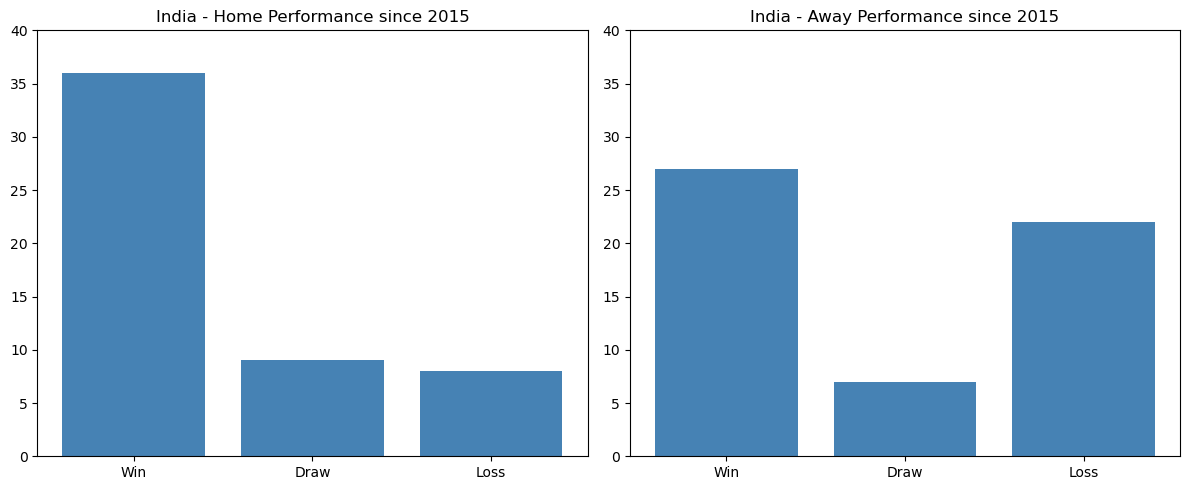

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize = (12,5))

#Home Performance
axes[0].bar(home_summary['Result'], home_summary['Count'], color = 'steelblue')
axes[0].set_title('India - Home Performance since 2015')
axes[0].set_ylim(0,40)
#Away Performance

axes[1].bar(away_summary['Result'], away_summary['Count'], color = 'steelblue')
axes[1].set_title('India - Away Performance since 2015')
axes[1].set_ylim(0,40)
#plot
plt.tight_layout()
plt.show()

In [42]:
home_win_pct = home_summary.loc[0, "Count"] / home_summary["Count"].sum() * 100
away_win_pct = away_summary.loc[0, "Count"] / away_summary["Count"].sum() * 100

print("Home Win %:", round(home_win_pct, 2))
print("Away Win %:", round(away_win_pct, 2))

Home Win %: 67.92
Away Win %: 48.21


In [43]:
def get_result(row):
    if pd.isna(row["winner"]):
        return "Draw"
    elif row["winner"] == country:
        return "Win"
    else:
        return "Loss"

df_country["result"] = df_country.apply(get_result, axis=1)

df_country["result"].value_counts()

result
Win     63
Loss    30
Draw    16
Name: count, dtype: int64

In [44]:
df_country["location"] = df_country.apply(
    lambda row: "Home" if row["home_team"] == country else "Away",
    axis=1
)

df_country["location"].value_counts()

location
Away    56
Home    53
Name: count, dtype: int64

In [45]:
grouped = df_country.groupby(["year", "location", "result"])["match_id"].count().reset_index()

grouped

,year,location,result,match_id
0,2015,Away,Loss,3
1,2015,Away,Win,4
2,2015,Home,Draw,2
3,2015,Home,Win,4
4,2016,Away,Loss,3
5,2016,Away,Win,2
6,2016,Home,Draw,1
7,2016,Home,Loss,2
8,2016,Home,Win,3
9,2017,Away,Draw,1


In [46]:
pivot = grouped.pivot_table(
    index=["year", "location"],
    columns="result",
    values="match_id",
    fill_value=0
).reset_index()

pivot

result,year,location,Draw,Loss,Win
0,2015,Away,0.0,3.0,4.0
1,2015,Home,2.0,0.0,4.0
2,2016,Away,0.0,3.0,2.0
3,2016,Home,1.0,2.0,3.0
4,2017,Away,1.0,3.0,4.0
5,2017,Home,1.0,0.0,2.0
6,2018,Away,1.0,4.0,1.0
7,2018,Home,0.0,2.0,2.0
8,2019,Away,1.0,2.0,2.0
9,2019,Home,1.0,0.0,6.0


In [47]:
df_country.groupby(["year", "venue"])["match_id"].count().unstack()

venue,Adelaide Oval,"Arun Jaitley Stadium, Delhi",Basin Reserve,"Basin Reserve, Wellington",Bellerive Oval,"Bellerive Oval, Hobart",Brisbane Cricket Ground,"Brisbane Cricket Ground, Woolloongabba","Brisbane Cricket Ground, Woolloongabba, Brisbane",Dubai International Cricket Stadium,...,Sophia Gardens,St George's Park,Sydney Cricket Ground,The Wanderers Stadium,Trent Bridge,"Vidarbha Cricket Association Stadium, Jamtha, Nagpur",W.A.C.A. Ground,Western Australia Cricket Association Ground,"Windsor Park, Roseau",Zahur Ahmed Chowdhury Stadium
year,,,,,,,,,,,,,,,,,,,,,
2015,1.0,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,...,1.0,NaN,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN
2016,1.0,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2017,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,1.0
2018,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN
2019,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2020,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN


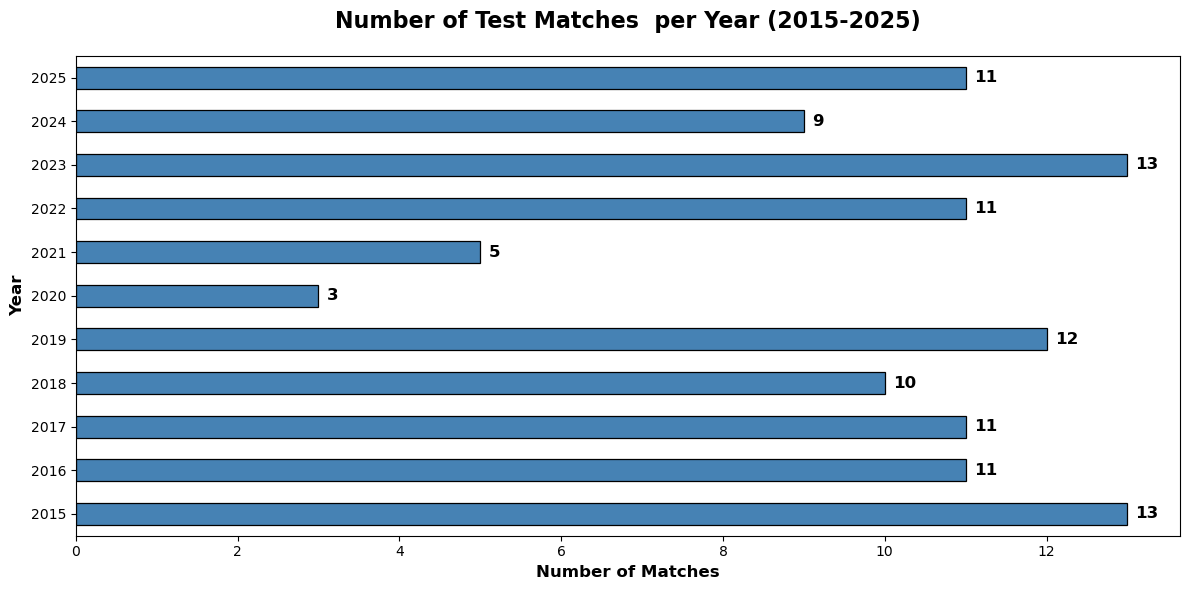

In [48]:
match_per_year = df_country['year'].value_counts().sort_index()

match_per_year.plot(kind = 'barh', figsize = (12,6), color = 'steelblue', edgecolor='black', linewidth=0.9)
plt.title('Number of Test Matches  per Year (2015-2025)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Number of Matches', fontsize=12, fontweight='bold')
plt.ylabel('Year', fontsize=12, fontweight='bold')

for i, value in enumerate(match_per_year):
    plt.text(
        value + 0.1,   # position (slightly right of bar)
        i,             # y position
        str(value),    # label
        va='center',
        fontsize=12,
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

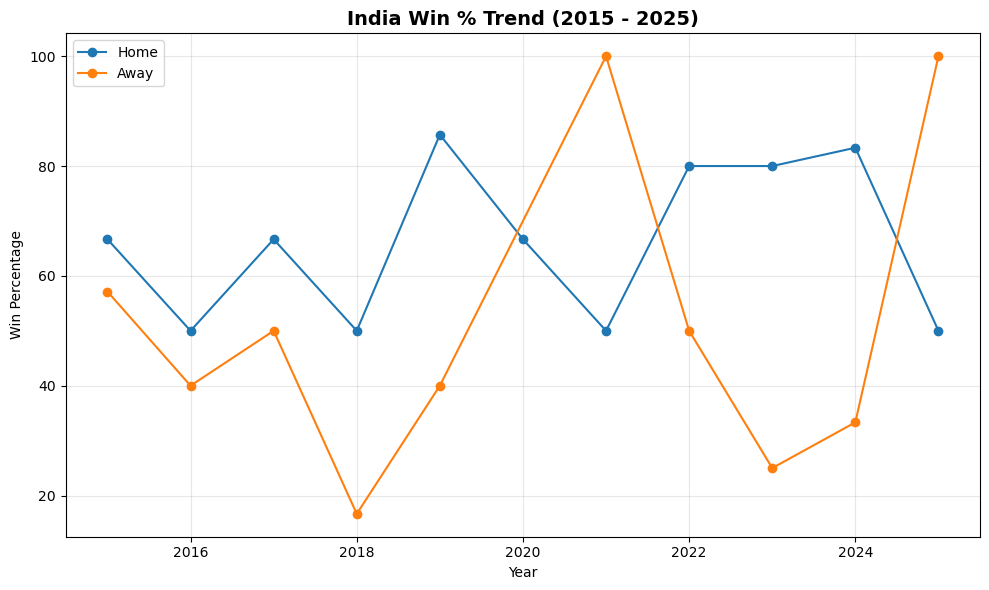

In [49]:
# Trend in Winning

pivot["total"] = pivot["Win"] + pivot["Draw"] + pivot["Loss"]
pivot["win_pct"] = (pivot["Win"] / pivot["total"]) * 100

home_trend = pivot[pivot["location"] == "Home"]
away_trend = pivot[pivot["location"] == "Away"]

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.plot(home_trend["year"], home_trend["win_pct"], marker='o', label="Home")
plt.plot(away_trend["year"], away_trend["win_pct"], marker='o', label="Away")

plt.title("India Win % Trend (2015 - 2025)", fontsize=14, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Win Percentage")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

India’s home dominance peaked between 2016–2019, remained strong till 2022, and shows a noticeable decline from 2023 onwards.

India’s home dominance has declined post-2022, with 2024 providing the strongest evidence due to a larger sample size.

While fluctuations exist due to varying match counts, 2024 — with a higher number of home matches — indicates a clear reduction in India’s home dominance compared to the 2016–2019 peak.”